---------------------------------------------------------------------------------------------------------------
# Time Series Analysis
---------------------------------------------------------------------------------------------------------------
## Content Log:
1. Import Libraries
2. Load Data
3. Date Time Conversion
4. Price Trends
5. Volume Trends
6. Combining datasets for Multi-ticker trends plot
7. Multi-ticker Combined Price Trends
8. Key Observations
---------------------------------------------------------------------------------------------------------------

# 01. Import Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# 02. Load data

In [2]:
data_path = "../../data/raw_data"
datasets = {}
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_path, file), low_memory=False)
        df["Ticker"] = file.replace(".csv", "")
        datasets[file] = df

# 03. Date Time Conversion

In [3]:
for df in datasets.values():
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df.sort_values("Date", inplace=True)

# 04. Price Trends

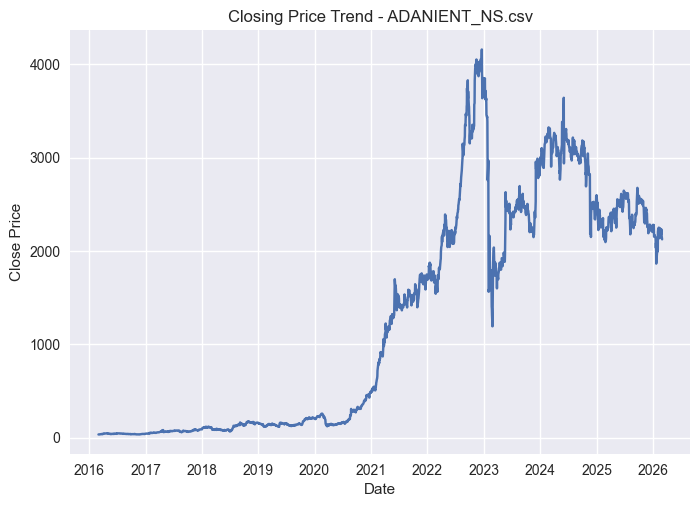

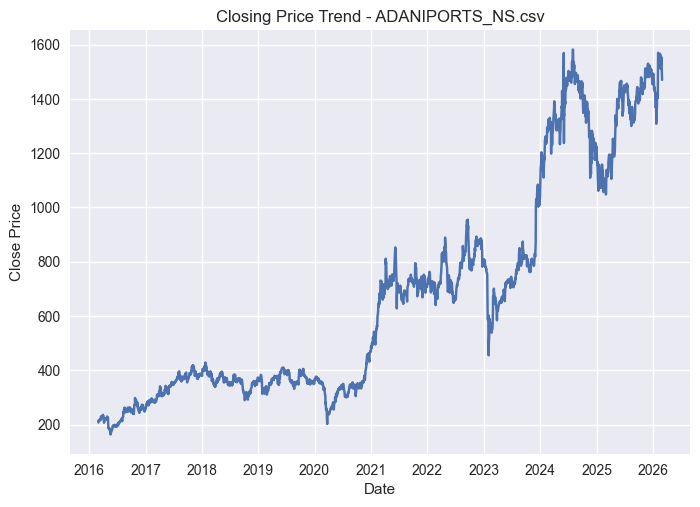

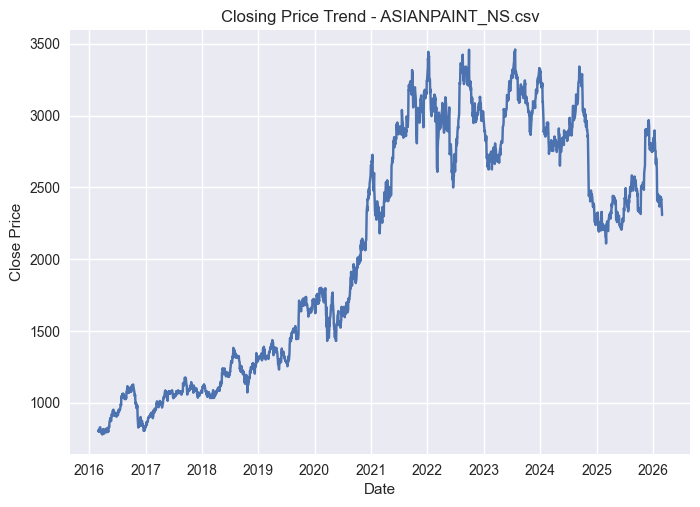

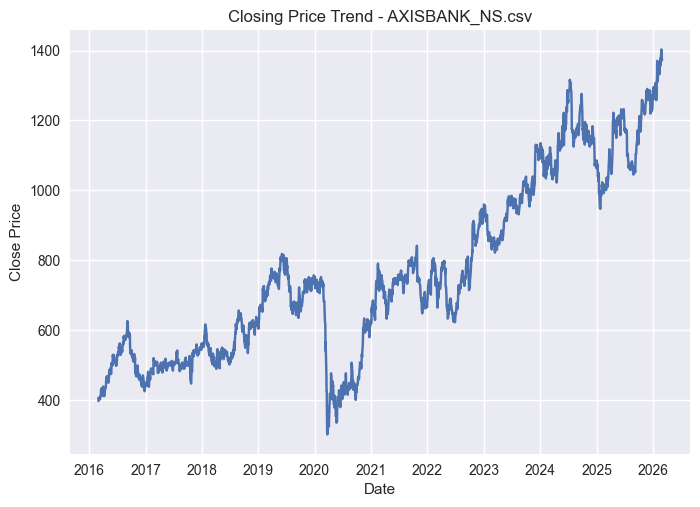

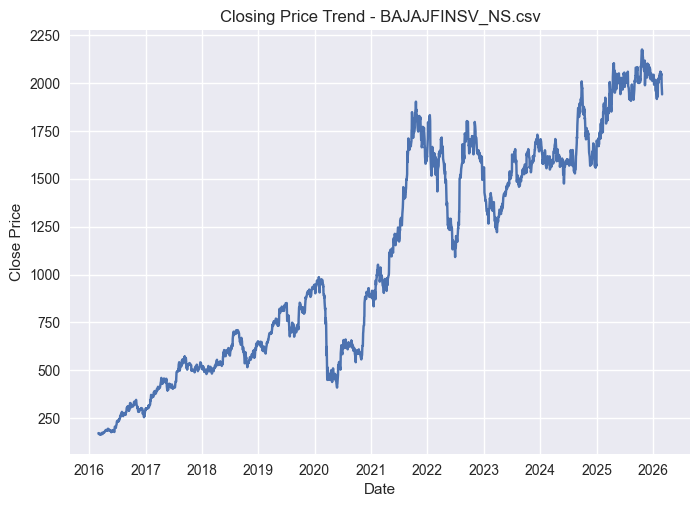

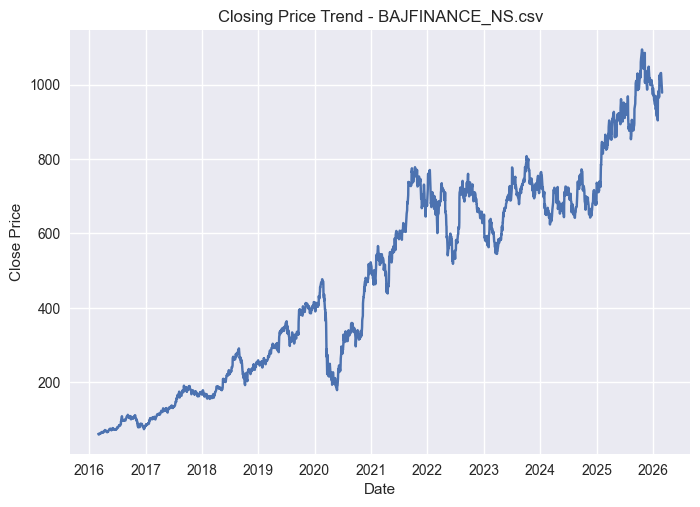

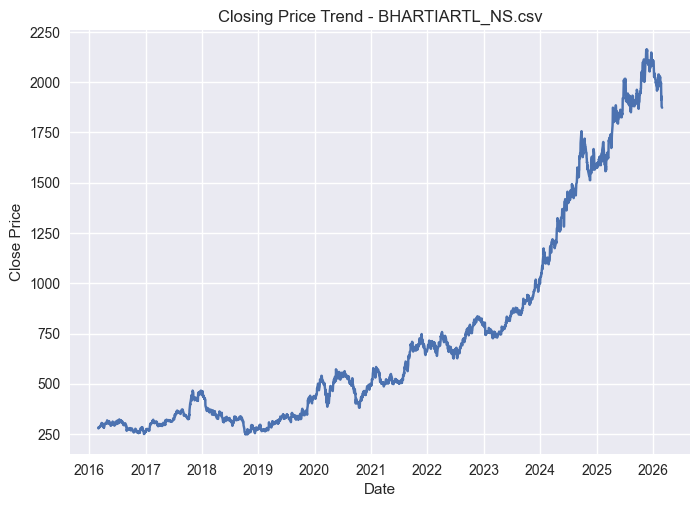

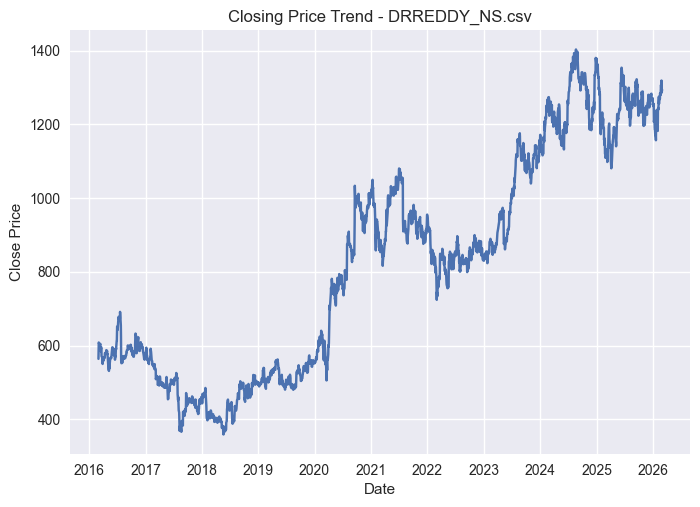

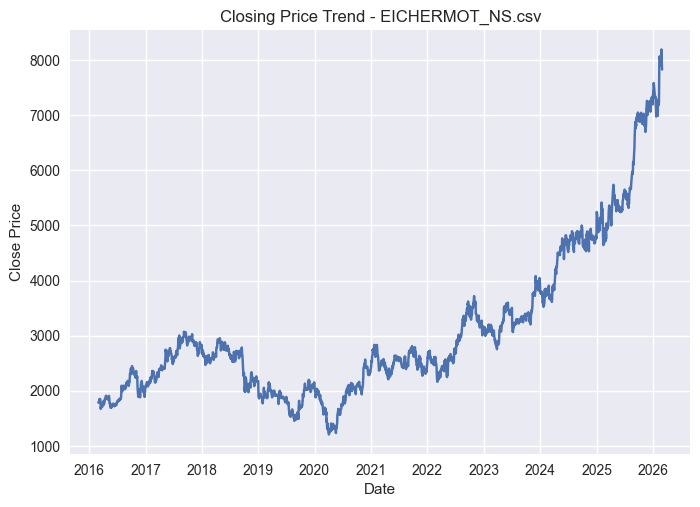

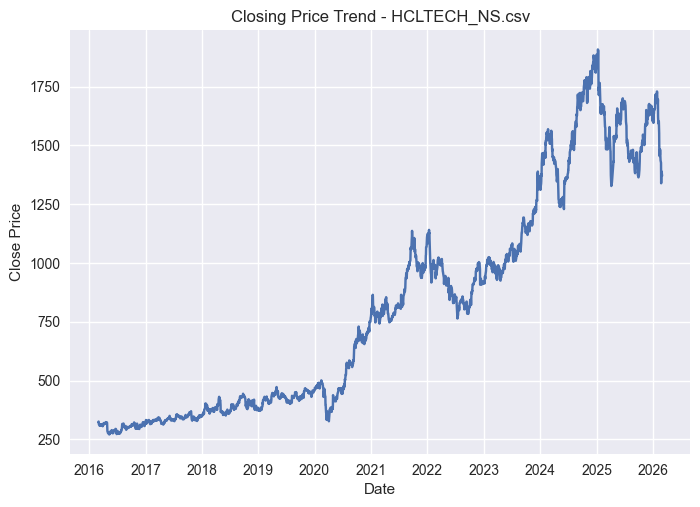

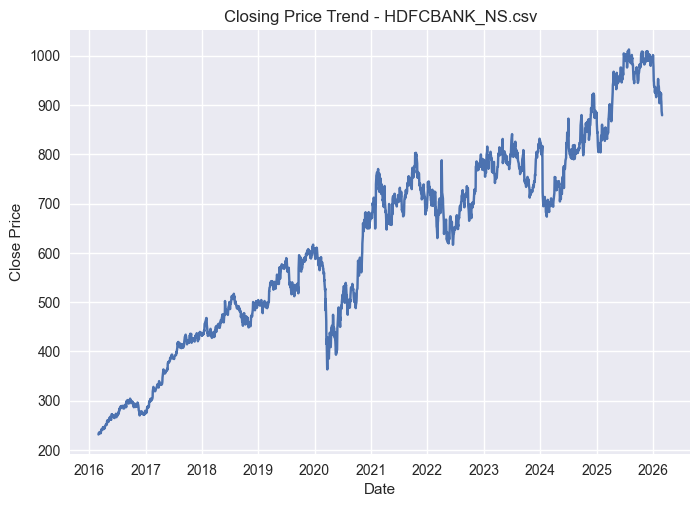

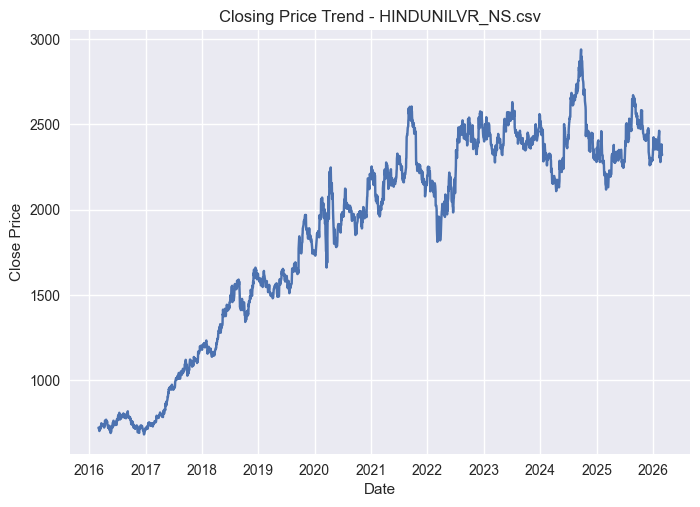

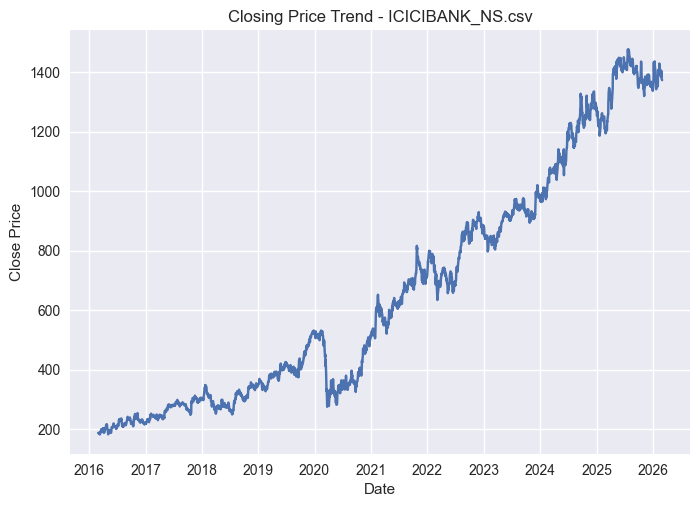

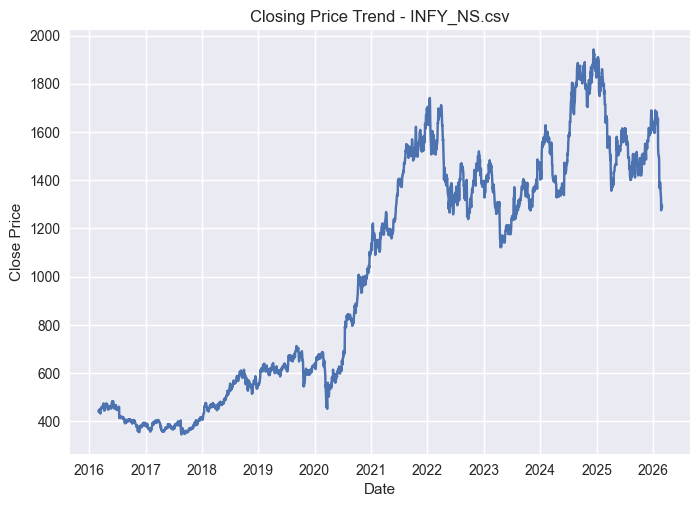

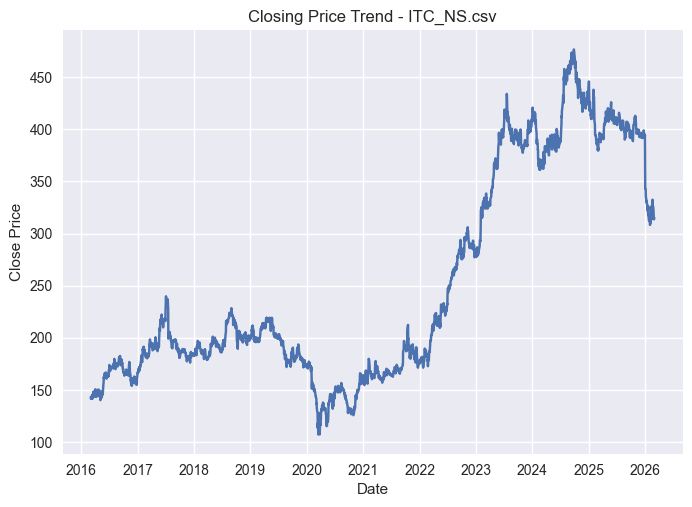

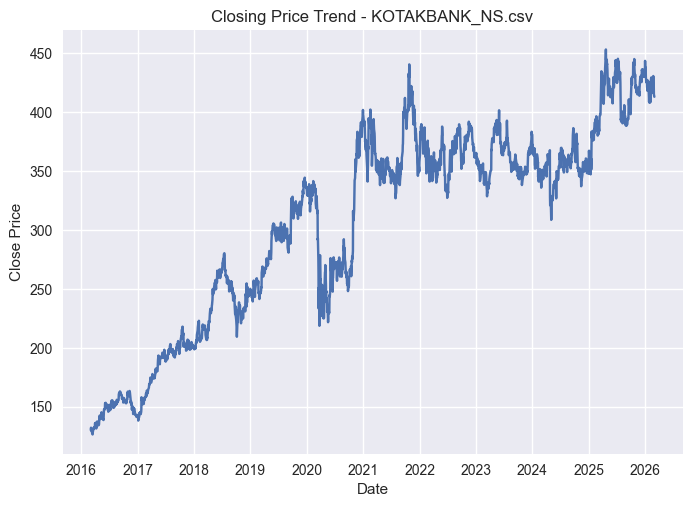

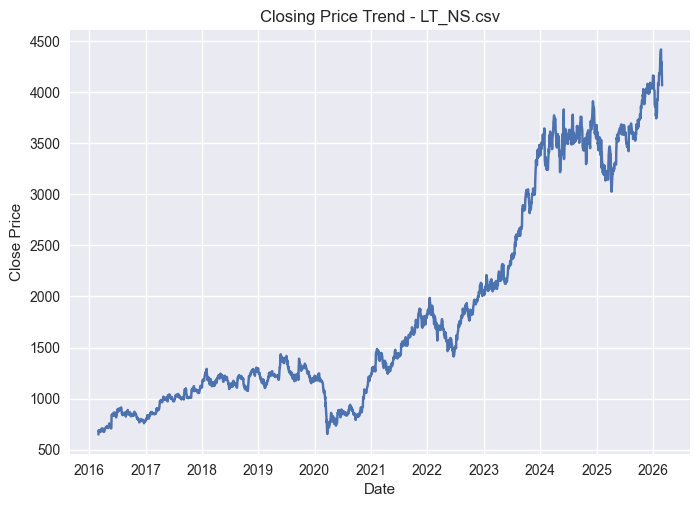

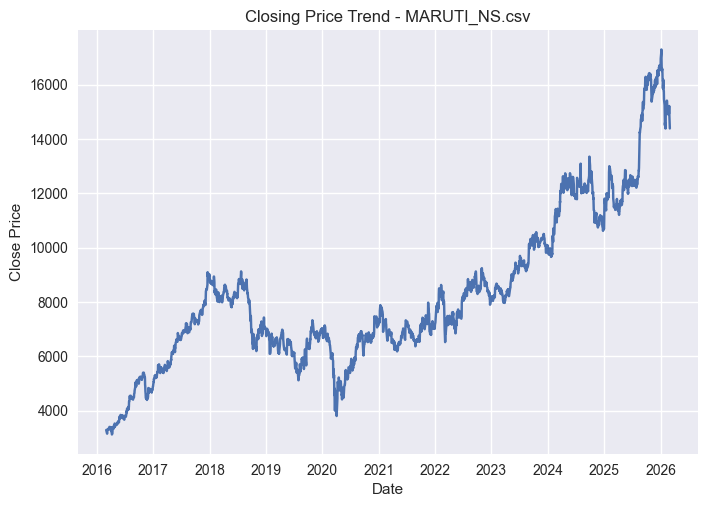

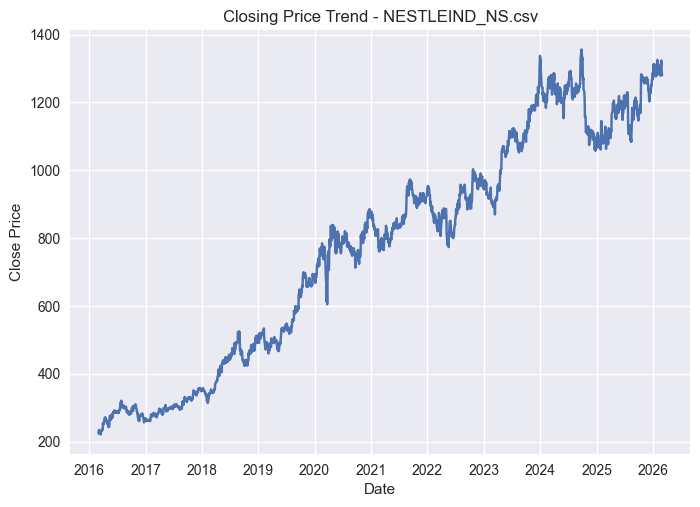

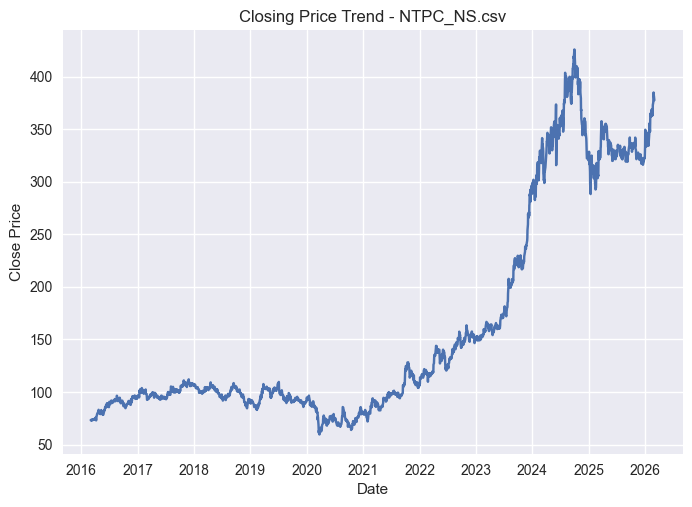

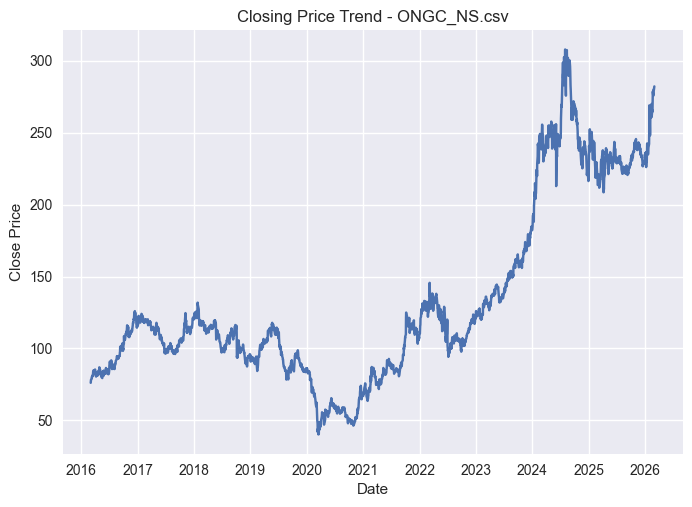

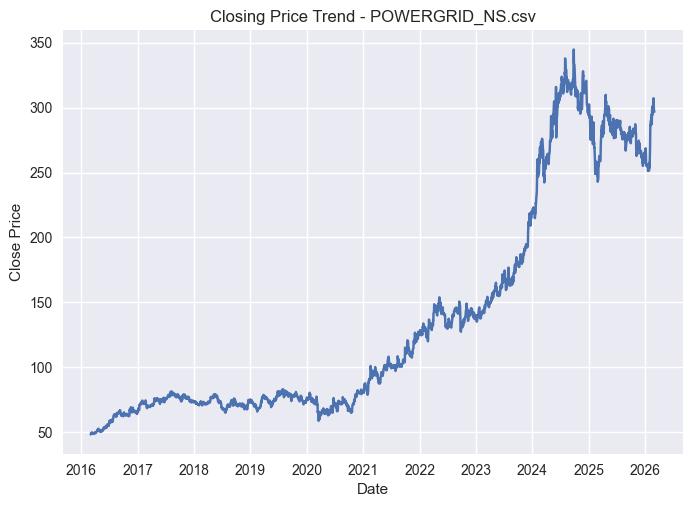

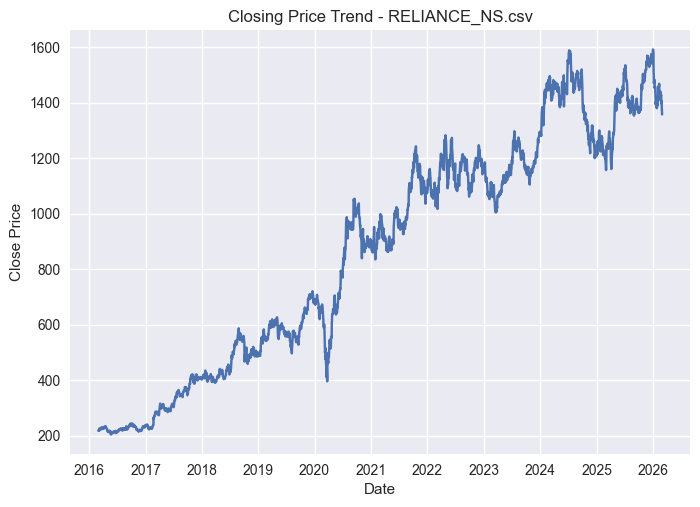

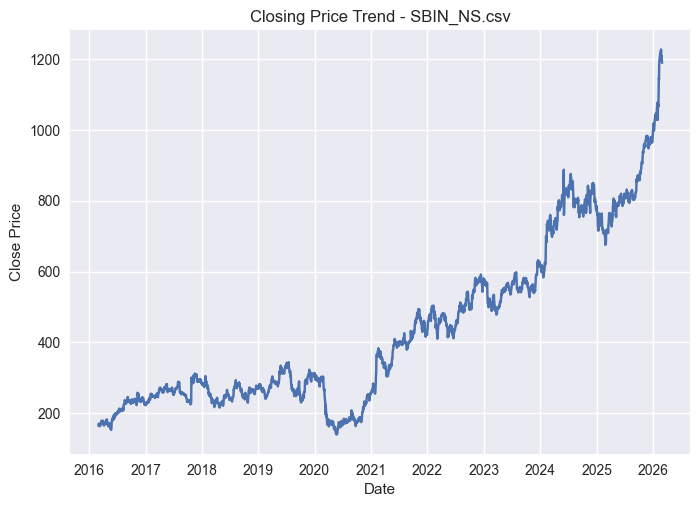

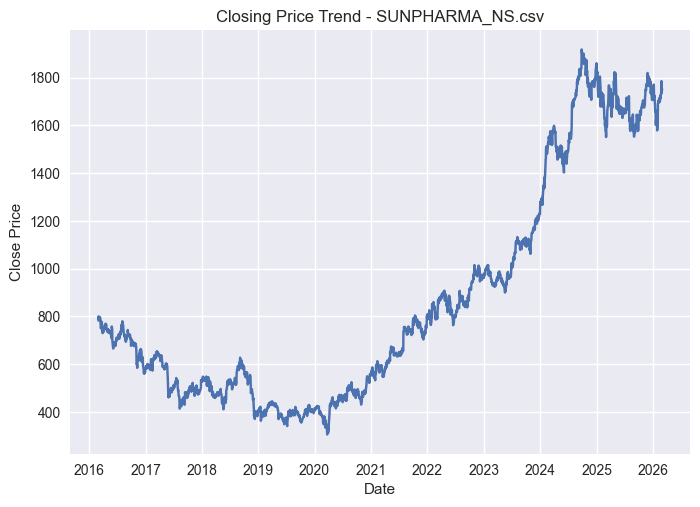

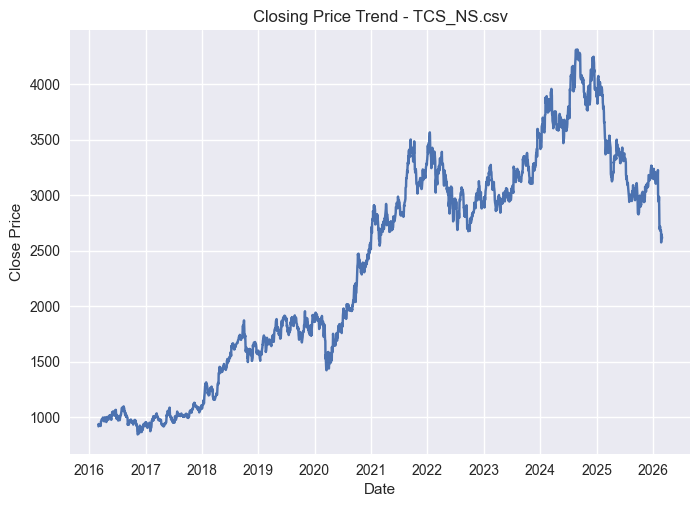

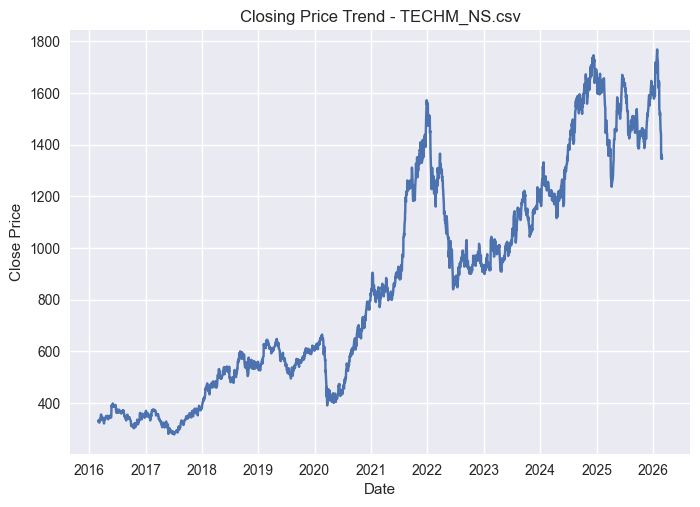

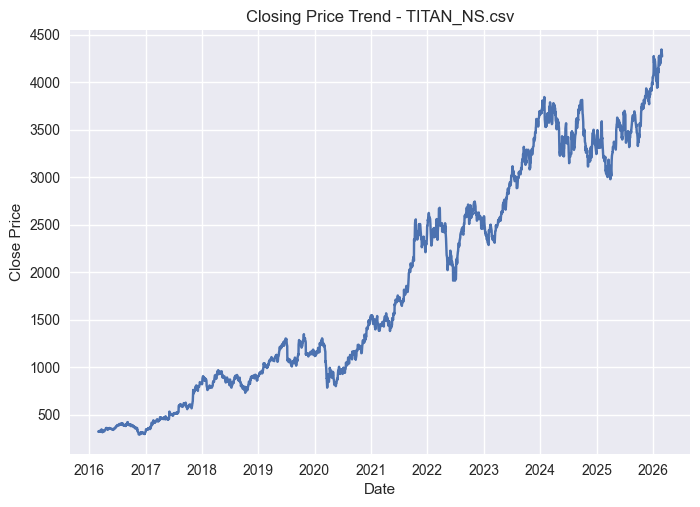

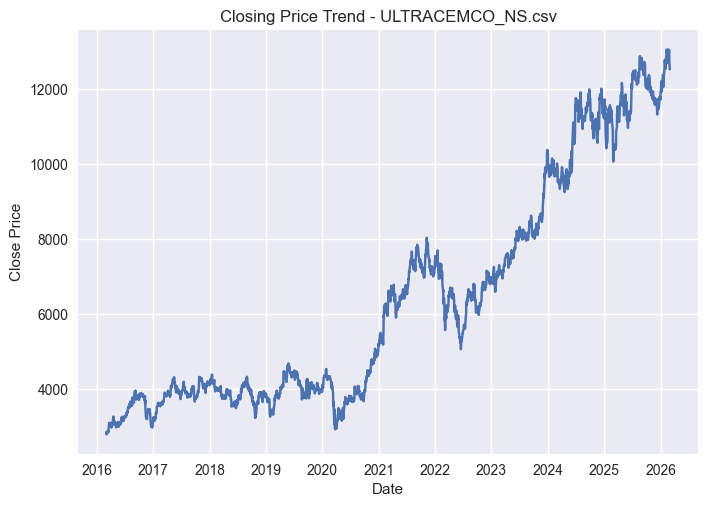

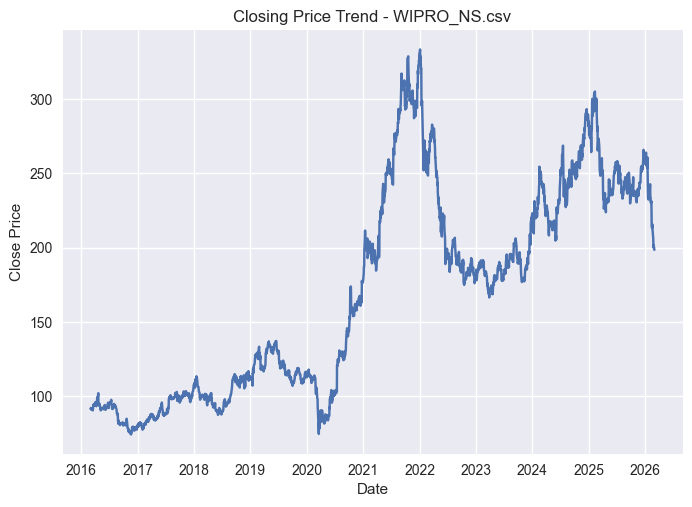

In [4]:
for name, df in datasets.items():
    if "Date" in df.columns and "Close" in df.columns:
        plt.figure()
        plt.plot(df["Date"], df["Close"])
        plt.title(f"Closing Price Trend - {name}")
        plt.xlabel("Date")
        plt.ylabel("Close Price")
        plt.show()

# 05. Volume Trends

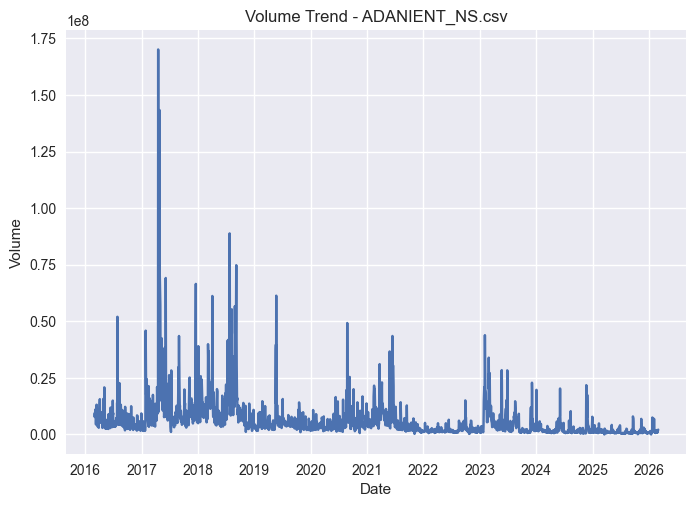

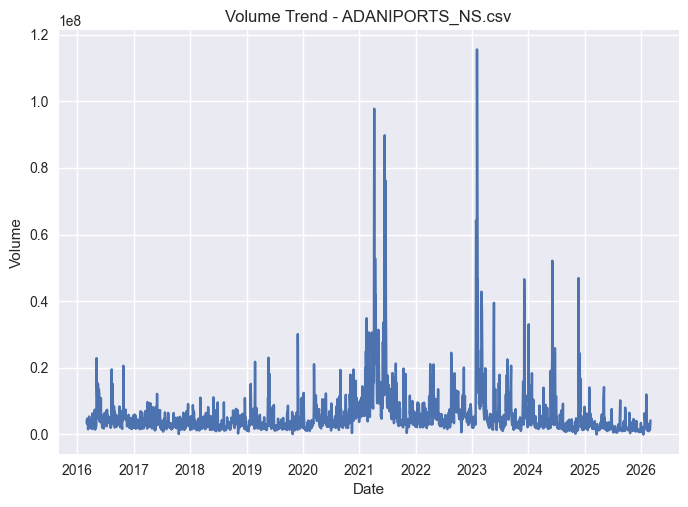

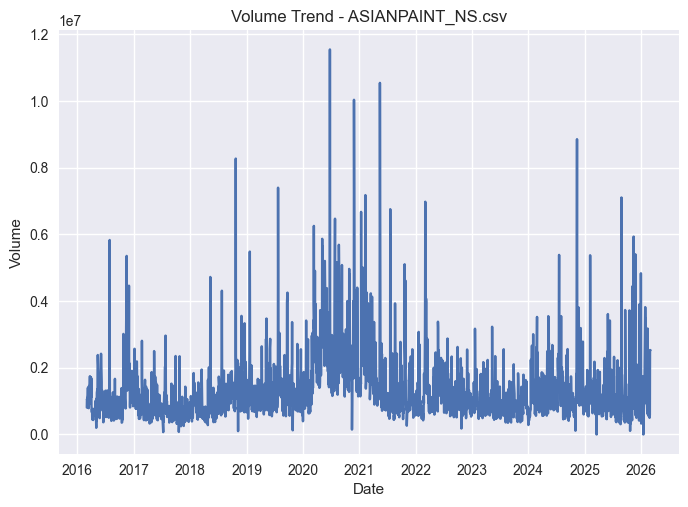

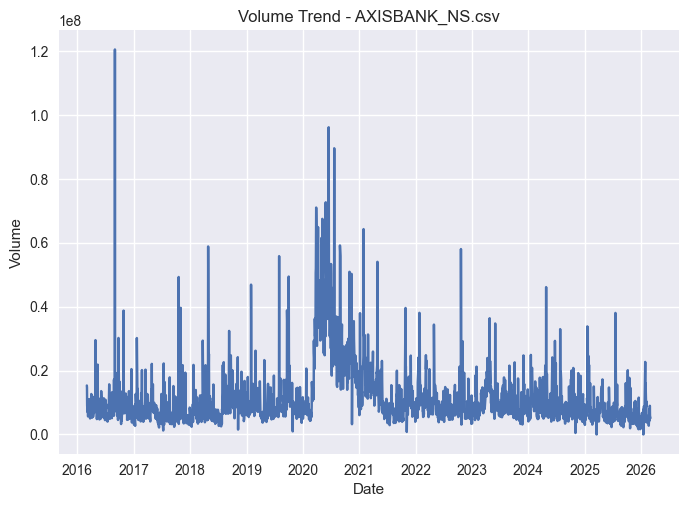

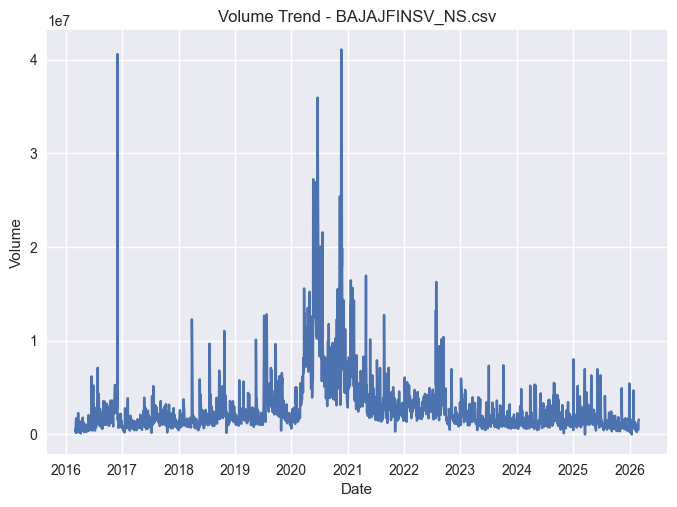

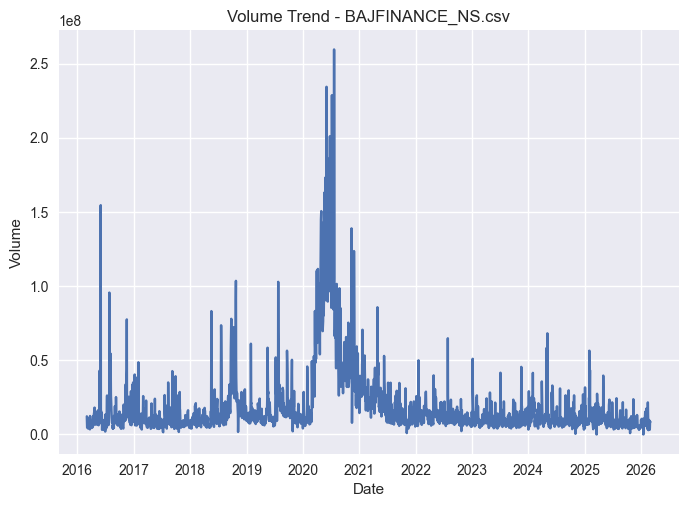

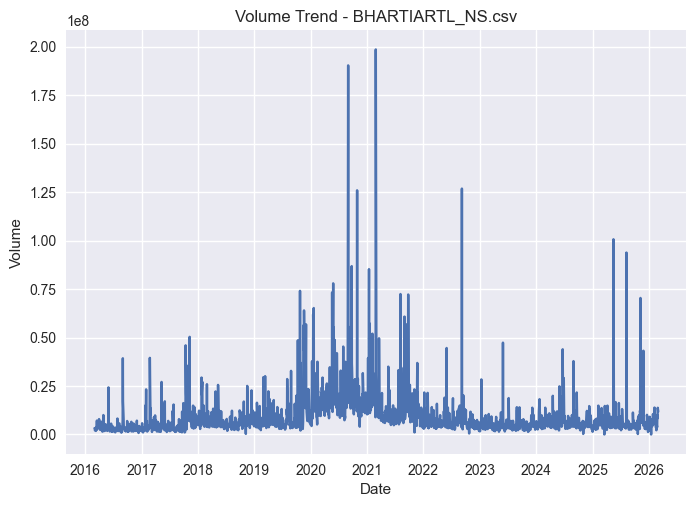

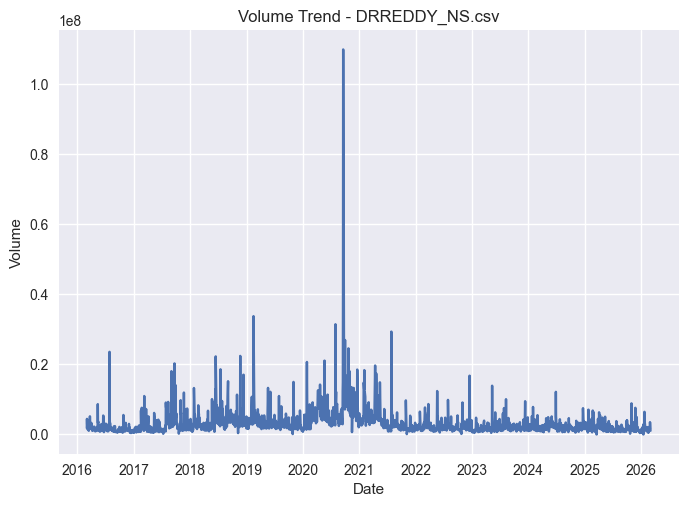

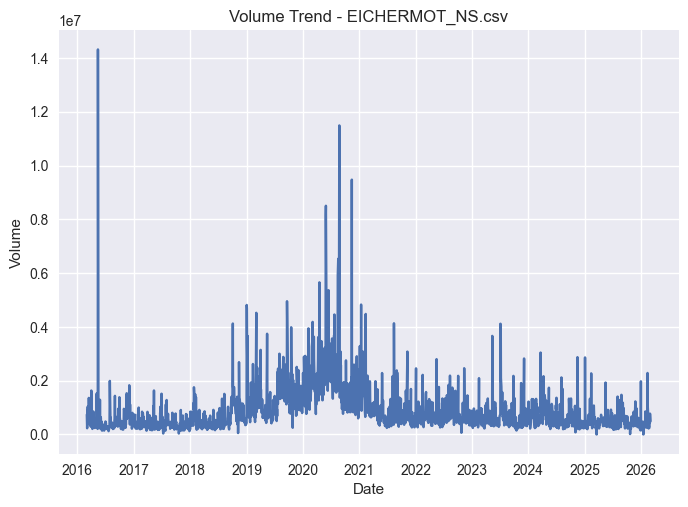

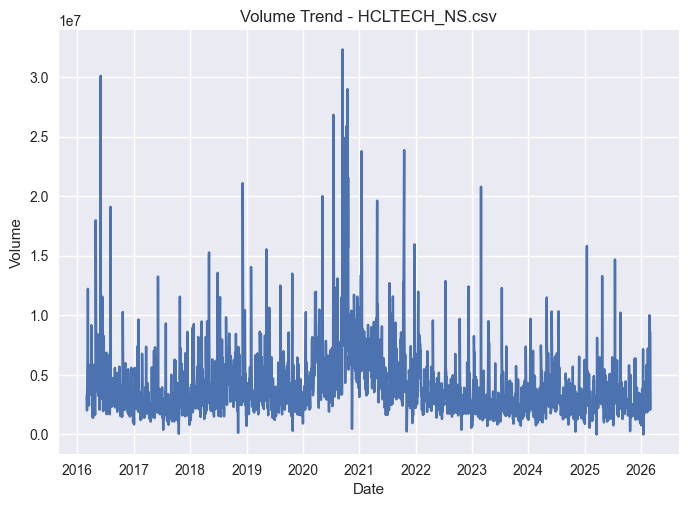

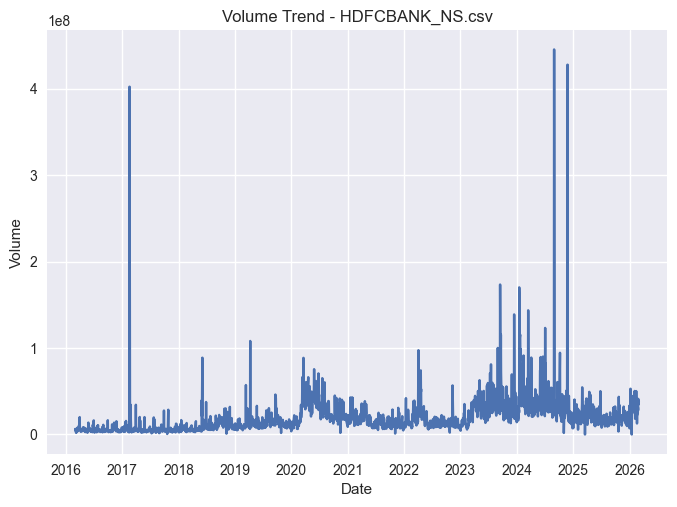

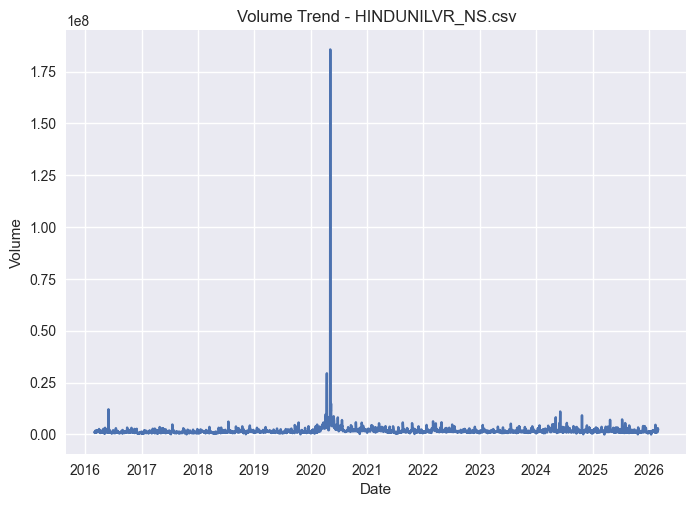

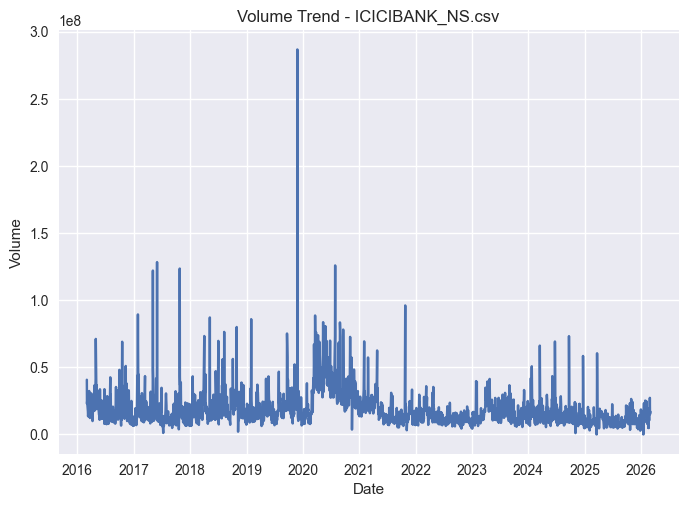

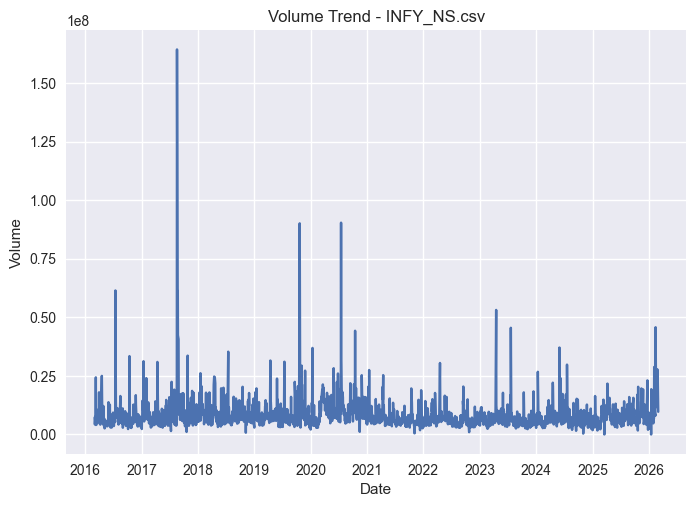

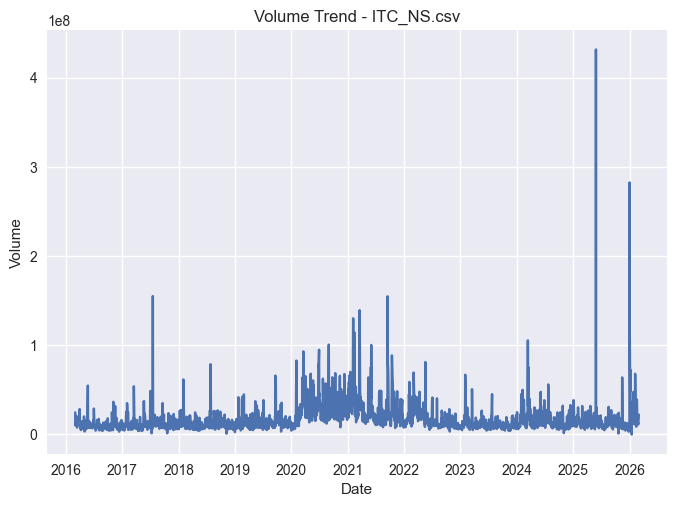

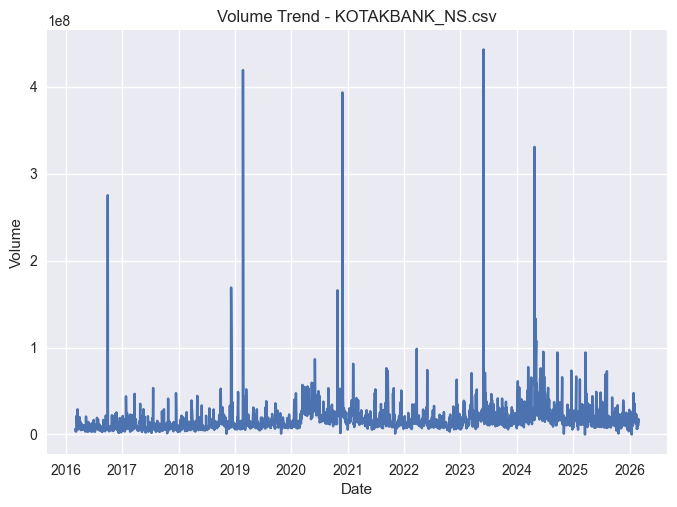

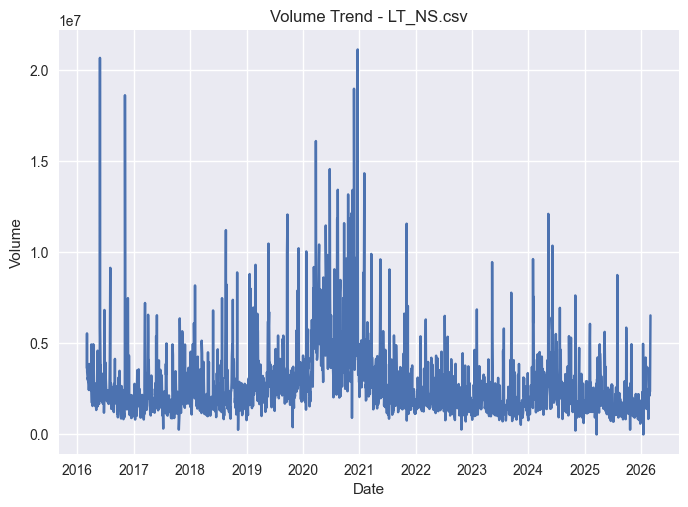

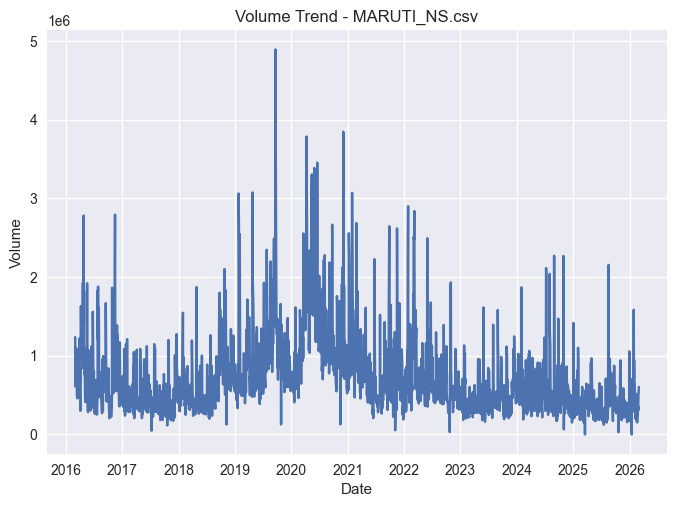

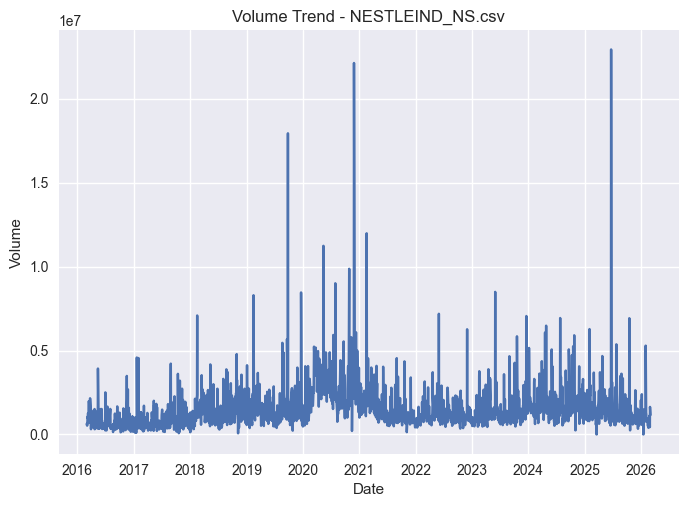

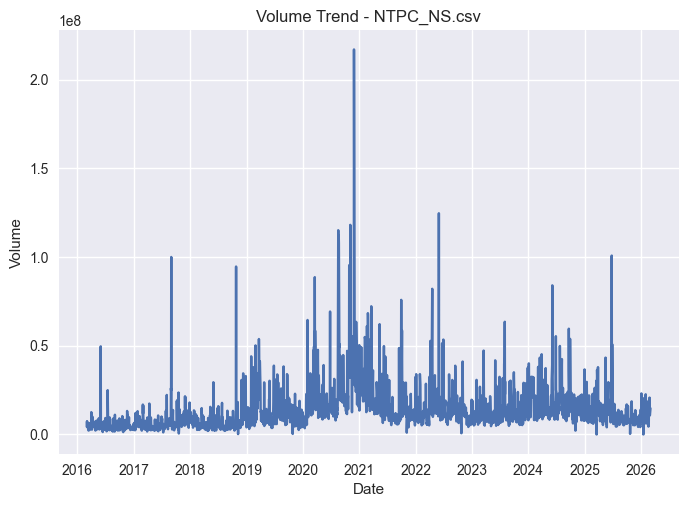

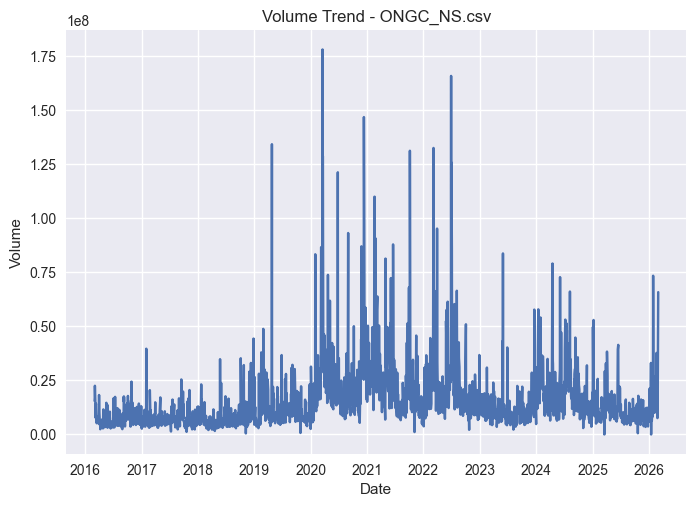

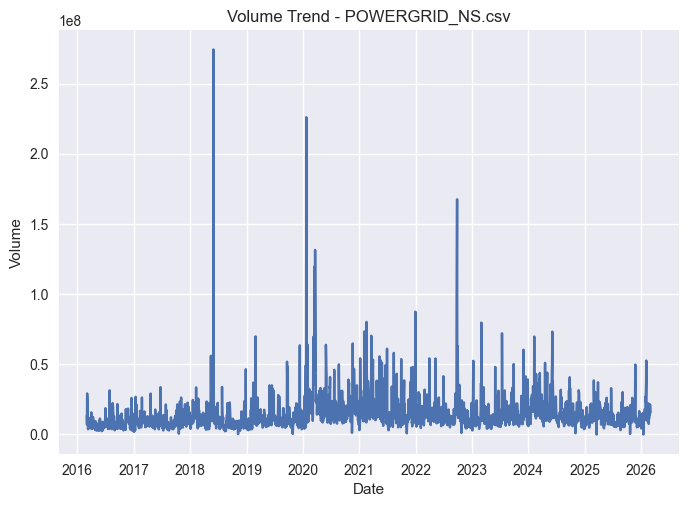

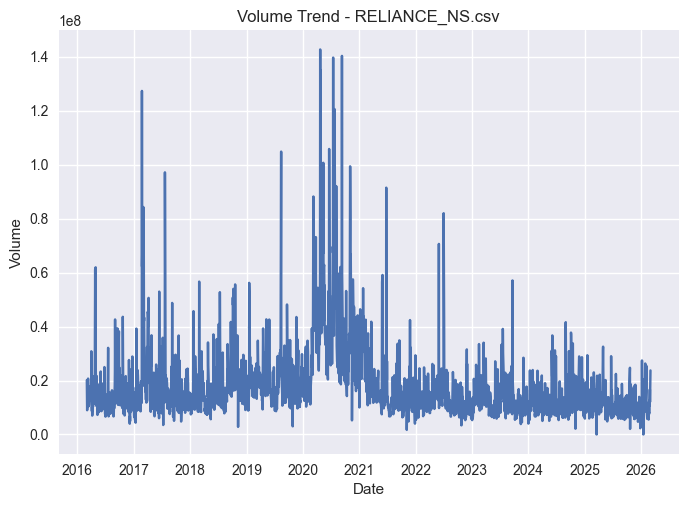

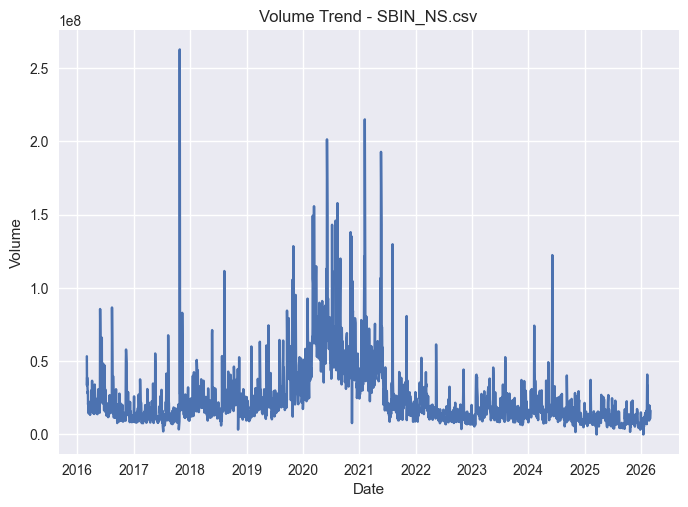

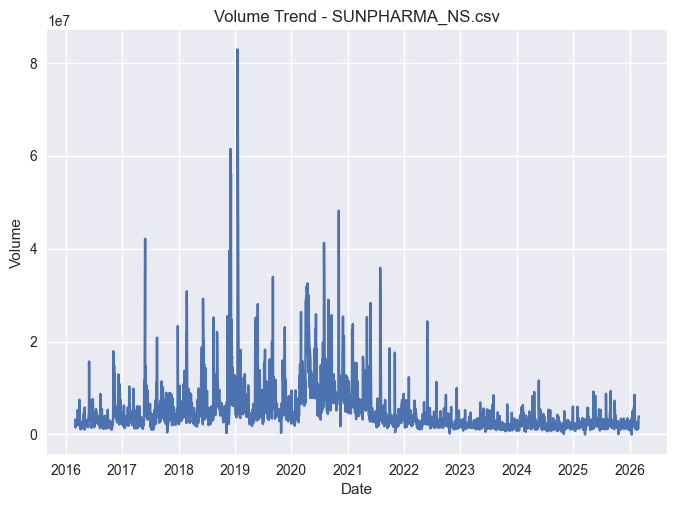

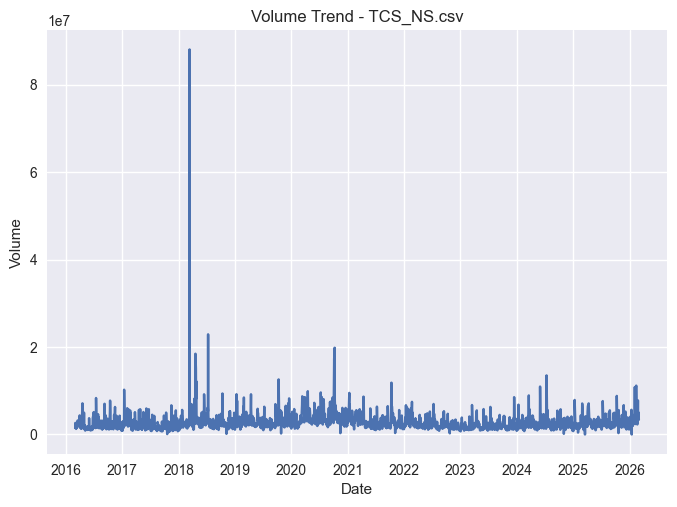

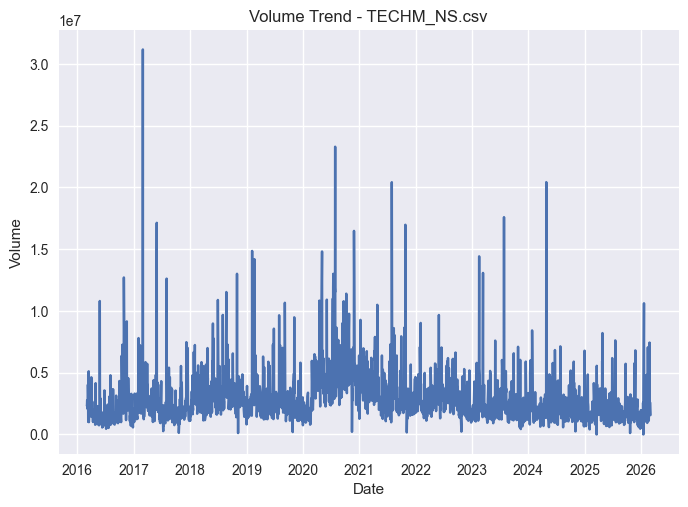

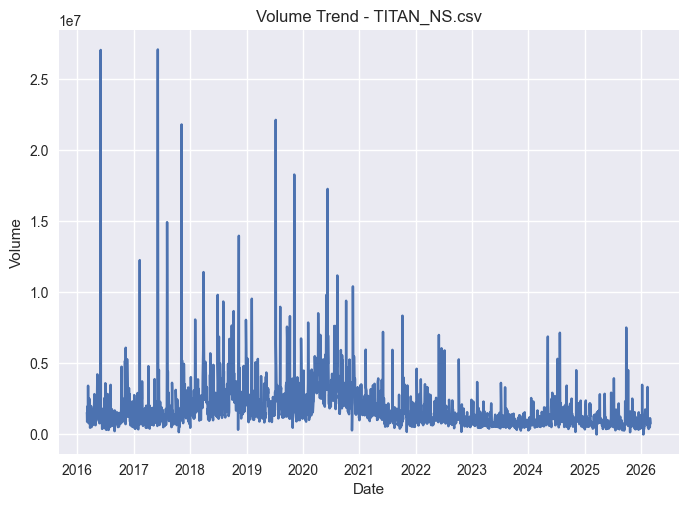

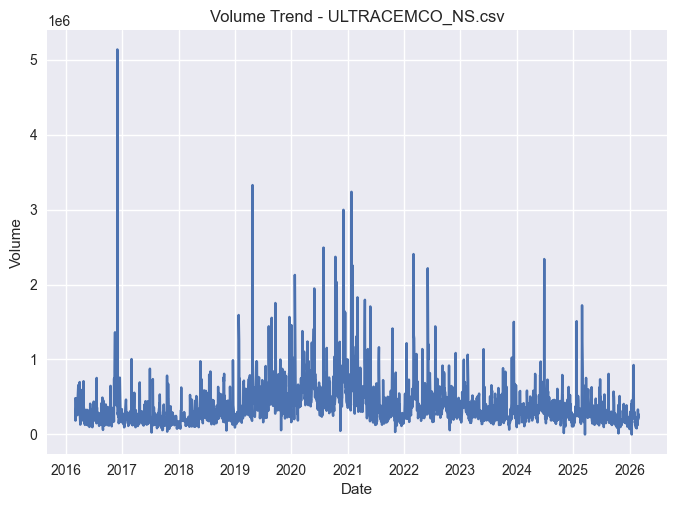

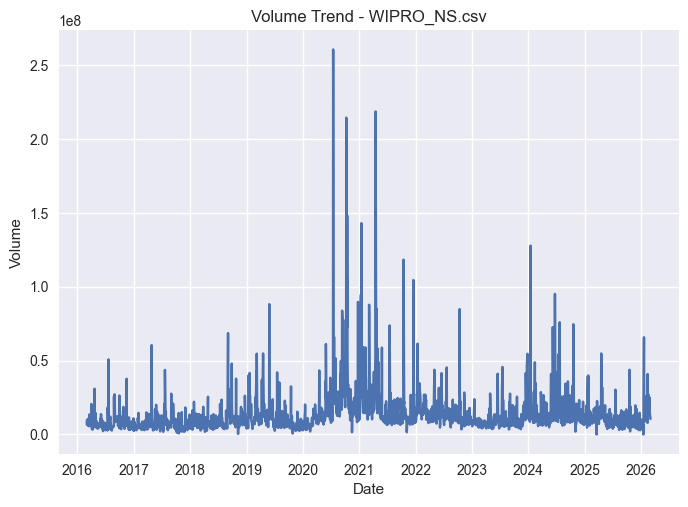

In [5]:
for name, df in datasets.items():
    if "Date" in df.columns and "Volume" in df.columns:
        plt.figure()
        plt.plot(df["Date"], df["Volume"])
        plt.title(f"Volume Trend - {name}")
        plt.xlabel("Date")
        plt.ylabel("Volume")
        plt.show()

# 06. Combining datasets for Multi-ticker trends plot

In [9]:
combined = pd.DataFrame()
for name, df in datasets.items():
    if "Date" in df.columns and "Close" in df.columns:
        temp = df[["Date", "Close"]].copy()
        temp.set_index("Date", inplace=True)
        temp.rename(columns={"Close": name.replace(".csv", "")}, inplace=True)
        if combined.empty:
            combined = temp
        else:
            combined = combined.join(temp, how="outer")

# 07. Multi-ticker Combined Price Trends

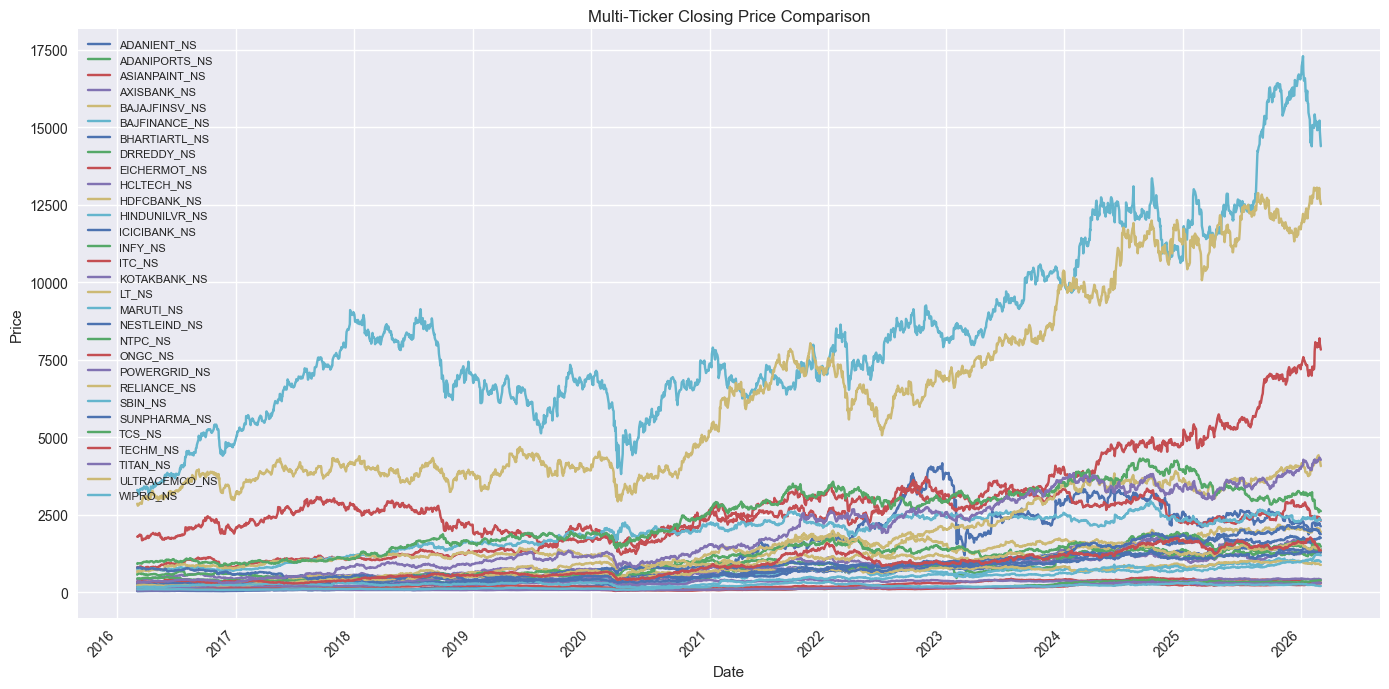

In [11]:
plt.figure(figsize=(14, 7))
combined.plot(ax=plt.gca())
plt.title("Multi-Ticker Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
save_path = "../../visuals_and_reports/eda_plots/multi_ticker_combined_price_trends.png"
plt.savefig(save_path)
plt.show()

# 08. Key Observations
1. According to **Price Trends** almost all stocks shows the up-trend in the price, **there was the market crash observed in the year slot of 2020**, the market research and the past informations shows that it was due to **Covid-19 Pandemic** which is the most possible reasons of market crash.
2. Overall **ADANIENT_NS** i.e. **Adani Enterprises** performed very well in past 10-years time-series; always **followed an up-trend**.
3. According to **Multi-ticker Combined Price Trends** the combined tickers also shows the growth of **ADANIENT** i.e. **Adani Enterprises**

For Advanced EDA report please refer to:
**root_dir/observations/advanced_eda_report.md**
[Advanced EDA report](../../observations/advanced_eda_report.md)